# 3. Preprocessing Pipeline — Updated

**Inputs:** `eicu_features.csv`, `mimic_features.csv`  
**Outputs:** `X_train.csv`, `X_val.csv`, `X_test.csv`, `X_mimic.csv`, `y_train`, `y_val`, `y_test`, `y_mimic`, `X_train_smote.csv`, `y_train_smote.csv`


# 1. Setup and Load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling  import SMOTE
from imblearn.combine        import SMOTETomek
from collections             import Counter


SEED = 42
np.random.seed(SEED)

BASE = '/content/drive/MyDrive/AI in Medicine/data/output_data'
EICU_PATH = f'{BASE}/eicu_train/eicu_features.csv'
MIMIC_PATH= f'{BASE}/mimic_val/mimic_features.csv'
OUT_DIR   = f'{BASE}/preprocessed'
os.makedirs(OUT_DIR, exist_ok=True)

print('Libraries loaded.')


Libraries loaded.


In [3]:
eicu = pd.read_csv(EICU_PATH)
mimic = pd.read_csv(MIMIC_PATH)

print(f'eICU shape: {eicu.shape}    mortality: {eicu["mortality"].mean():.3f}')
print(f'MIMIC shape: {mimic.shape}  mortality: {mimic["mortality"].mean():.3f}')

eICU shape: (2520, 73)    mortality: 0.050
MIMIC shape: (136, 74)  mortality: 0.338


# 2. Column Matching

The EDA shows **column naming mismatch** between the two datasets:

| Domain | eICU column | MIMIC column |
|---|---|---|
| Heart rate | `heartrate_*` | `hr_*` |
| Respiration | `respiration_*` | `rr_*` |
| SpO2 | `sao2_*` | `spo2_*` |
| Systolic BP | `ssystolic_*` | `sbp_*` |
| Diastolic BP | `sdiastolic_*` | `dbp_*` |
| Mean arterial pressure | `systemicmean_*` | `map_*` |

We rename eICU columns to the MIMIC convention so both datasets share identical column names.

In [4]:
VITAL_RENAME = {}
for stat in ['min', 'max', 'mean']:
    VITAL_RENAME[f'heartrate_{stat}'] = f'hr_{stat}'
    VITAL_RENAME[f'respiration_{stat}'] = f'rr_{stat}'
    VITAL_RENAME[f'sao2_{stat}']        = f'spo2_{stat}'
    VITAL_RENAME[f'ssystolic_{stat}']   = f'sbp_{stat}'
    VITAL_RENAME[f'sdiastolic_{stat}']  = f'dbp_{stat}'
    VITAL_RENAME[f'systemicmean_{stat}']= f'map_{stat}'

eicu = eicu.rename(columns=VITAL_RENAME)

# Verify shared columns
shared = sorted(set(eicu.columns) & set(mimic.columns))
eicu_only  = sorted(set(eicu.columns)  - set(mimic.columns))
mimic_only = sorted(set(mimic.columns) - set(eicu.columns))

print(f'Shared columns : {len(shared)}')
print(f'eICU-only      : {eicu_only}')
print(f'MIMIC-only     : {mimic_only}')

Shared columns : 73
eICU-only      : []
MIMIC-only     : ['hadm_id']


In [5]:
# Align both to the same shared column set
# MIMIC has hadm_id which eICU does not — drop it

keep_cols = [c for c in shared if c not in ['hadm_id']]
eicu  = eicu[keep_cols].copy()
mimic = mimic[keep_cols].copy()

print(f'eICU  aligned: {eicu.shape}')
print(f'MIMIC aligned: {mimic.shape}')
print(f'Columns: {eicu.columns.tolist()}')

eICU  aligned: (2520, 73)
MIMIC aligned: (136, 73)
Columns: ['admit_source', 'age_clean', 'albumin_max', 'albumin_mean', 'albumin_min', 'alt_max', 'alt_mean', 'alt_min', 'bicarbonate_max', 'bicarbonate_mean', 'bicarbonate_min', 'bun_max', 'bun_mean', 'bun_min', 'careunit', 'creatinine_max', 'creatinine_mean', 'creatinine_min', 'dataset', 'dbp_max', 'dbp_mean', 'dbp_min', 'ethnicity_grp', 'gender_binary', 'glucose_max', 'glucose_mean', 'glucose_min', 'hematocrit_max', 'hematocrit_mean', 'hematocrit_min', 'hemoglobin_max', 'hemoglobin_mean', 'hemoglobin_min', 'hr_max', 'hr_mean', 'hr_min', 'icd9_chapter', 'icu_los_days', 'inr_max', 'inr_mean', 'inr_min', 'lactate_max', 'lactate_mean', 'lactate_min', 'map_max', 'map_mean', 'map_min', 'mortality', 'platelets_max', 'platelets_mean', 'platelets_min', 'potassium_max', 'potassium_mean', 'potassium_min', 'rr_max', 'rr_mean', 'rr_min', 'sbp_max', 'sbp_mean', 'sbp_min', 'sodium_max', 'sodium_mean', 'sodium_min', 'spo2_max', 'spo2_mean', 'spo2_min

## 3. Drop leaky and ID columns

**`icu_los_days`** must be dropped, because it is **label-leaky**.

The logis is: Length of ICU stay is only known at discharge, which is the **same time** we know the mortality outcome. Including it would give the model access to **future info**

**`stay_id`** and **`dataset`** are identifiers, not clinical features.

In [6]:
DROP_COLS = ['stay_id', 'dataset', 'icu_los_days']

eicu  = eicu.drop(columns=[c for c in DROP_COLS if c in eicu.columns])
mimic = mimic.drop(columns=[c for c in DROP_COLS if c in mimic.columns])

print(f'After dropping leaky/ID columns:')
print(f'  eICU : {eicu.shape}')
print(f'  MIMIC: {mimic.shape}')

After dropping leaky/ID columns:
  eICU : (2520, 70)
  MIMIC: (136, 70)


# 4. Missing values


*   ## We decide what to do with each column based on EDA results
*  ## ! We can't remove: Lactate, BUN, and BP/INR features even if they exceed 70% missing in eICU,
   because EDA showed high correlation with target AND BP/INR are well-measured in MIMIC (~3% missing).
   Dropping them based on eICU missingness alone would destroy signal in the external test set.



**general cleaning for others:**
- `> 70% missing` → drop the feature entirely (too sparse to reliably impute)
  - **Exception:** BP (SBP/DBP/MAP) and INR — high missing in eICU (~84%/74%) but low in MIMIC (~3%/20%). Keep and flag.
- `40–70% missing` → keep but flag (albumin, lactate, ALT — imputing them introduces more bias than dropping)
- `< 40% missing` → impute (median for numeric, mode for categorical)


In [7]:
miss_eicu  = eicu.isnull().mean().sort_values(ascending=False)
miss_mimic = mimic.isnull().mean().sort_values(ascending=False)

miss_df = pd.DataFrame({
    'eICU_missing':  miss_eicu,
    'MIMIC_missing': miss_mimic
}).dropna(how='all')

miss_df['max_missing'] = miss_df.max(axis=1)
miss_df = miss_df[miss_df['max_missing'] > 0].sort_values('max_missing', ascending=False)

print('Features with missingness > 0 (sorted by worst):')
print(miss_df.to_string())

Features with missingness > 0 (sorted by worst):
                  eICU_missing  MIMIC_missing  max_missing
temp_max              0.939683       0.933824     0.939683
temp_mean             0.939683       0.933824     0.939683
temp_min              0.939683       0.933824     0.939683
hemoglobin_max        0.218254       0.875000     0.875000
hemoglobin_mean       0.218254       0.875000     0.875000
hemoglobin_min        0.218254       0.875000     0.875000
dbp_max               0.842063       0.029412     0.842063
dbp_mean              0.842063       0.029412     0.842063
dbp_min               0.842063       0.029412     0.842063
sbp_max               0.841667       0.029412     0.841667
sbp_min               0.841667       0.029412     0.841667
sbp_mean              0.841667       0.029412     0.841667
map_min               0.840873       0.029412     0.840873
map_mean              0.840873       0.029412     0.840873
map_max               0.840873       0.029412     0.840873
lactate

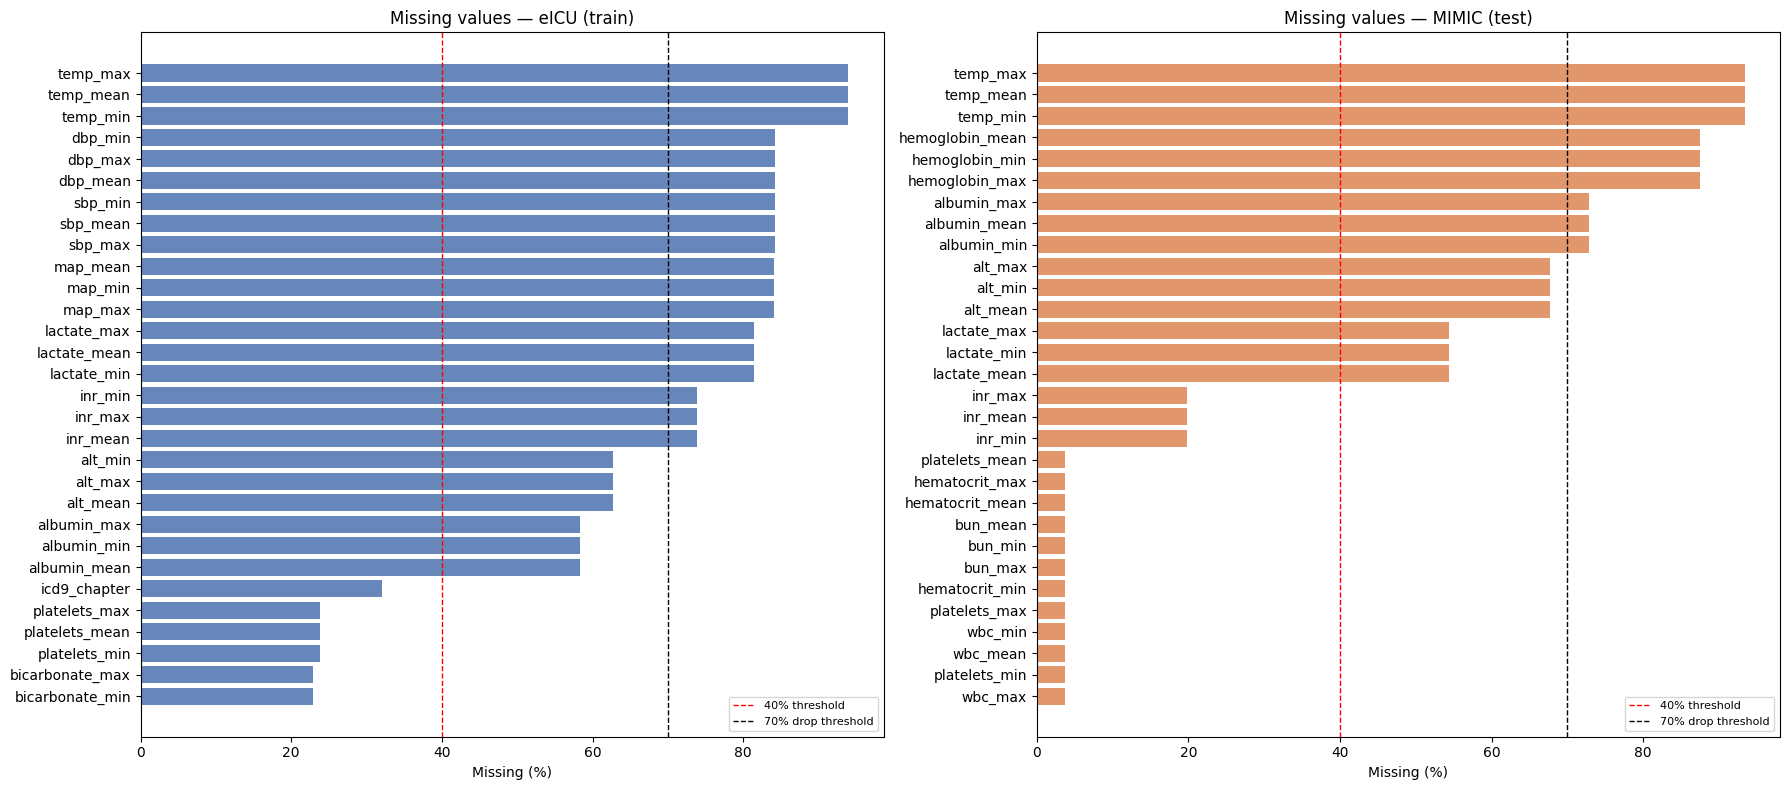

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, miss, name, color in zip(
    axes,
    [miss_eicu, miss_mimic],
    ['eICU (train)', 'MIMIC (test)'],
    ['#4C72B0', '#DD8452']
):
    top = miss[miss > 0].head(30)
    ax.barh(top.index[::-1], top.values[::-1] * 100, color=color, alpha=0.85)
    ax.axvline(40, color='red',    linestyle='--', linewidth=1, label='40% threshold')
    ax.axvline(70, color='black',  linestyle='--', linewidth=1, label='70% drop threshold')
    ax.set_xlabel('Missing (%)')
    ax.set_title(f'Missing values — {name}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
# UPDATE SUGGESTION: PROTECT_FEATURES extended to include BP/INR columns.
# Reason: SBP/DBP/MAP are ~84% missing in eICU but only ~3% in MIMIC; INR ~74% vs ~20%.
# Dropping them would erase meaningful signal in the external test set.
DROP_THRESHOLD = 0.70

cols_to_drop = miss_eicu[miss_eicu > DROP_THRESHOLD].index.tolist()

PROTECT_FEATURES = ['lactate_max', 'lactate_min', 'lactate_mean',
                    'bun_max',     'bun_min',     'bun_mean',
                    'sbp_max',     'sbp_min',     'sbp_mean',
                    'dbp_max',     'dbp_min',     'dbp_mean',
                    'map_max',     'map_min',     'map_mean',
                    'inr_max',     'inr_min',     'inr_mean']

cols_to_drop = [c for c in cols_to_drop if c not in PROTECT_FEATURES]

print(f'Columns to DROP (>{DROP_THRESHOLD*100:.0f}% missing in eICU):')
for c in cols_to_drop:
    print(f'  {c}: {miss_eicu[c]*100:.1f}% missing')

eicu  = eicu.drop(columns=cols_to_drop)
mimic = mimic.drop(columns=[c for c in cols_to_drop if c in mimic.columns])

print(f'\nAfter dropping high-missingness features:')
print(f'  eICU : {eicu.shape}')
print(f'  MIMIC: {mimic.shape}')


Columns to DROP (>70% missing in eICU):
  temp_max: 94.0% missing
  temp_mean: 94.0% missing
  temp_min: 94.0% missing

After dropping high-missingness features:
  eICU : (2520, 67)
  MIMIC: (136, 67)


## 5. Separate features and target + train/val/test split

We split **before** any fitting (imputer, scaler) to prevent data leakage.  
The MIMIC dataset is never touched during fitting — it is the external test set.

In [10]:
from sklearn.model_selection import train_test_split
from collections import Counter

TARGET = 'mortality'
X_eicu = eicu.drop(columns=[TARGET])
y_eicu = eicu[TARGET].astype(int)

# 2. Также подготовим MIMIC (если вы этого еще не сделали)
X_mimic = mimic.drop(columns=[TARGET])
y_mimic = mimic[TARGET].astype(int)

In [11]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Split train/val/test = 60/20/20
# 1. Test (20% from whole eICU)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_eicu, y_eicu,
    test_size=0.20,
    stratify=y_eicu,
    random_state=SEED
)

# 2. X_temp now split to Train and Val.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25, # 25% from 80% gives 20% оf general set
    stratify=y_temp,
    random_state=SEED
)

print('Split summary:')
print(f'  eICU train : {X_train.shape}  mortality={y_train.mean():.3f}')
print(f'  eICU val   : {X_val.shape}    mortality={y_val.mean():.3f}')
print(f'  eICU test  : {X_test.shape}   mortality={y_test.mean():.3f}')
print(f'  MIMIC ext  : {X_mimic.shape}  mortality={y_mimic.mean():.3f}')

print('\nClass distribution in eICU train set:')
train_counts = Counter(y_train)
print(f'  Survived (0): {train_counts[0]}  ({train_counts[0]/len(y_train)*100:.1f}%)')
print(f'  Died     (1): {train_counts[1]}  ({train_counts[1]/len(y_train)*100:.1f}%)')
print(f'  Ratio: {train_counts[0]/train_counts[1]:.1f}:1')

Split summary:
  eICU train : (1512, 66)  mortality=0.050
  eICU val   : (504, 66)    mortality=0.050
  eICU test  : (504, 66)   mortality=0.050
  MIMIC ext  : (136, 66)  mortality=0.338

Class distribution in eICU train set:
  Survived (0): 1436  (95.0%)
  Died     (1): 76  (5.0%)
  Ratio: 18.9:1


## 6. Outlier capping

Lab values contain physiologically impossible values (e.g. ALT = 5,610 from EDA) caused by data entry errors.  
We cap at **1st–99th percentile**, computed on the **training set only**, then apply the same clip bounds to val and MIMIC.

In [12]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Compute percentile bounds on train set only
clip_bounds = {}
for col in numeric_cols:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)

# Apply to all splits
for col in numeric_cols:
    lo, hi = clip_bounds[col]
    for df in [X_train, X_val, X_test, X_mimic]:
        df[col] = df[col].clip(lo, hi)

print(f'Winsorisation applied to {len(numeric_cols)} numeric features.')
print('Example bounds (creatinine_max):', clip_bounds.get('creatinine_max', 'N/A'))

Winsorisation applied to 62 numeric features.
Example bounds (creatinine_max): (np.float64(0.35441), np.float64(8.3204))


# 7. Missingness Imputation

# Strategy chosen from EDA findings:

| Feature group | Missing rate (eICU) | Missing rate (MIMIC) | Strategy | Rationale |
|---|---|---|---|---|
| albumin, lactate, ALT | 40–63% | 55–73% | Median + `_was_missing` flag | Clinically important; missingness predicts severity |
| SBP, DBP, MAP, INR | 74–84% | 3–20% | Keep + `_was_missing` flag | Critical vitals; well-measured in MIMIC — must not drop |
| Other labs/vitals | < 40% | < 40% | Median | Robust to skewed lab distributions |
| Categorical (careunit, etc.) | < 5% | < 5% | Mode | Simple; low impact |

**Key rule:** Imputer is **fit on `X_train` only**, then `.transform()` is applied to `X_val` and `X_mimic`. Never re-fit on test data.


In [13]:
# 1: Add missingness indicator flags for high-missingness features

# These features have 40-63% missingness AND high value

# The fact that a lab was NOT ordered is itself informative (sicker patients may or may not have tests ordered depending on protocol)

HIGH_MISS_FEATURES = ['albumin', 'lactate', 'alt']  # base names
FLAG_COLS = []

for base in HIGH_MISS_FEATURES:
    # Find all columns with this base name
    related = [c for c in numeric_cols if base in c.lower()]
    if related:
        flag_name = f'{base}_was_missing'
        # Create flag: 1 if ALL related columns are missing, 0 otherwise
        for df in [X_train, X_val, X_test, X_mimic]:
            df[flag_name] = df[related].isnull().all(axis=1).astype(int)
        FLAG_COLS.append(flag_name)
        print(f'  Flag created: {flag_name}  |  train positive rate: {X_train[flag_name].mean():.3f}')

print(f'\n{len(FLAG_COLS)} missingness indicator flags added.')

  Flag created: albumin_was_missing  |  train positive rate: 0.563
  Flag created: lactate_was_missing  |  train positive rate: 0.810
  Flag created: alt_was_missing  |  train positive rate: 0.607

3 missingness indicator flags added.


In [14]:
# UPDATE SUGGESTION: add missingness flags for BP and INR before imputation.
# Same logic as albumin/lactate/alt flags — absence of measurement is clinically informative.
BP_INR_BASES = ['sbp', 'dbp', 'map', 'inr']
for base in BP_INR_BASES:
    related = [c for c in X_train.columns if c.startswith(base + '_') and 'was_missing' not in c]
    if not related:
        print(f'Skipped {base} — columns not present')
        continue
    flag_name = f'{base}_was_missing'
    for df_ in [X_train, X_val, X_test, X_mimic]:
        df_[flag_name] = df_[related].isnull().all(axis=1).astype(int)
    FLAG_COLS.append(flag_name)
    print(f'  Flag created: {flag_name}  |  train rate: {X_train[flag_name].mean():.3f}')


  Flag created: sbp_was_missing  |  train rate: 0.846
  Flag created: dbp_was_missing  |  train rate: 0.846
  Flag created: map_was_missing  |  train rate: 0.845
  Flag created: inr_was_missing  |  train rate: 0.752


In [15]:
# Verify flags exist in all splits including MIMIC
for name, df in [('X_train', X_train), ('X_val', X_val),
                  ('X_test', X_test), ('X_mimic', X_mimic)]:
    flag_check = [c for c in df.columns if 'was_missing' in c]
    print(f'{name}: flags = {flag_check}')

X_train: flags = ['albumin_was_missing', 'lactate_was_missing', 'alt_was_missing', 'sbp_was_missing', 'dbp_was_missing', 'map_was_missing', 'inr_was_missing']
X_val: flags = ['albumin_was_missing', 'lactate_was_missing', 'alt_was_missing', 'sbp_was_missing', 'dbp_was_missing', 'map_was_missing', 'inr_was_missing']
X_test: flags = ['albumin_was_missing', 'lactate_was_missing', 'alt_was_missing', 'sbp_was_missing', 'dbp_was_missing', 'map_was_missing', 'inr_was_missing']
X_mimic: flags = ['albumin_was_missing', 'lactate_was_missing', 'alt_was_missing', 'sbp_was_missing', 'dbp_was_missing', 'map_was_missing', 'inr_was_missing']


In [16]:
# 2: Numeric imputation with median

# Refresh numeric cols list (flags are already 0/1)

numeric_cols_to_impute = X_train.select_dtypes(include=np.number).columns.tolist()
numeric_cols_to_impute = [c for c in numeric_cols_to_impute if c not in FLAG_COLS]

num_imputer = SimpleImputer(strategy='median')
num_imputer.fit(X_train[numeric_cols_to_impute])   # ← fit on TRAIN only

X_train[numeric_cols_to_impute] = num_imputer.transform(X_train[numeric_cols_to_impute])
X_val[numeric_cols_to_impute]   = num_imputer.transform(X_val[numeric_cols_to_impute])
X_test[numeric_cols_to_impute]   = num_imputer.transform(X_test[numeric_cols_to_impute])
X_mimic[numeric_cols_to_impute] = num_imputer.transform(X_mimic[numeric_cols_to_impute])

print(f'Numeric imputation done ({len(numeric_cols_to_impute)} columns).')
print(f'Remaining NaN in X_train (numeric): {X_train[numeric_cols_to_impute].isnull().sum().sum()}')

Numeric imputation done (62 columns).
Remaining NaN in X_train (numeric): 0


In [17]:
# 3: Categorical imputation with mode

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')

if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    cat_imputer.fit(X_train[cat_cols])  # fit on TRAIN only

    X_train[cat_cols] = cat_imputer.transform(X_train[cat_cols])
    X_val[cat_cols]   = cat_imputer.transform(X_val[cat_cols])
    X_test[cat_cols]   = cat_imputer.transform(X_test[cat_cols])
    X_mimic[cat_cols] = cat_imputer.transform(X_mimic[cat_cols])

    print(f'Categorical imputation done. Remaining NaN: {X_train[cat_cols].isnull().sum().sum()}')
else:
    print('No categorical columns with NaN found.')

Categorical columns: ['admit_source', 'careunit', 'ethnicity_grp', 'icd9_chapter']
Categorical imputation done. Remaining NaN: 0


# 8. Categorical encoding

* We one-hot encode: `careunit`, `admit_source`, `ethnicity_grp`, `icd9_chapter`.


* We use `pd.get_dummies` fitted on the train set, then `.reindex()` to force MIMIC to match the exact column set — filling any unseen categories with 0.

In [18]:
# UPDATE SUGGESTION: drop_first=True added to prevent the dummy variable trap.
# Without it, one OHE column is a linear combination of the others — causes multicollinearity in LR/SVM.
CAT_ENCODE_COLS = [c for c in ['careunit', 'admit_source', 'ethnicity_grp', 'icd9_chapter']
                   if c in X_train.columns]

print(f'Encoding: {CAT_ENCODE_COLS}')

X_train = pd.get_dummies(X_train, columns=CAT_ENCODE_COLS, drop_first=True, dtype=int)
train_cols_after_ohe = X_train.columns.tolist()

X_val   = pd.get_dummies(X_val,   columns=CAT_ENCODE_COLS, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=CAT_ENCODE_COLS, drop_first=True, dtype=int)
X_mimic = pd.get_dummies(X_mimic, columns=CAT_ENCODE_COLS, drop_first=True, dtype=int)

X_val   = X_val.reindex(columns=train_cols_after_ohe,   fill_value=0)
X_test  = X_test.reindex(columns=train_cols_after_ohe,  fill_value=0)
X_mimic = X_mimic.reindex(columns=train_cols_after_ohe, fill_value=0)

print(f'\nFinal feature count: {X_train.shape[1]}')
print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'X_mimic : {X_mimic.shape}')
print(f'Column mismatch: {set(X_train.columns) - set(X_mimic.columns)}')


Encoding: ['careunit', 'admit_source', 'ethnicity_grp', 'icd9_chapter']

Final feature count: 100
X_train : (1512, 100)
X_val   : (504, 100)
X_test  : (504, 100)
X_mimic : (136, 100)
Column mismatch: set()


# 9. Scaling

`StandardScaler` (zero mean, unit variance) — **fit on `X_train` only**.
Required for Logistic Regression, SVM, and MLP. Tree-based models (RF, XGBoost) don't need it.

**Applied to continuous numeric features only.** OHE dummy columns and binary flags (0/1) are left unchanged — standardizing them would distort their meaning and hurt linear model interpretability.


In [19]:
# UPDATE SUGGESTION: scale continuous features only — OHE dummies and binary flags should not be standardized.
# Standardizing a 0/1 dummy distorts its meaning and can hurt interpretability and tree splits.
CAT_BASES    = ['careunit', 'admit_source', 'ethnicity_grp', 'icd9_chapter']
flag_cols    = [c for c in X_train.columns if 'was_missing' in c]
binary_names = set(['gender_binary'] + flag_cols)

all_numeric     = X_train.select_dtypes(include=np.number).columns.tolist()
ohe_cols        = [c for c in all_numeric if any(c.startswith(b + '_') for b in CAT_BASES)]
continuous_cols = [c for c in all_numeric if c not in set(ohe_cols) | binary_names]

scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])  # fit on TRAIN only

def scale_df(df, cont_cols, fitted_scaler):
    df_out = df.copy()
    df_out[cont_cols] = fitted_scaler.transform(df[cont_cols])
    return df_out

X_train_scaled = scale_df(X_train, continuous_cols, scaler)
X_val_scaled   = scale_df(X_val,   continuous_cols, scaler)
X_test_scaled  = scale_df(X_test,  continuous_cols, scaler)
X_mimic_scaled = scale_df(X_mimic, continuous_cols, scaler)

print(f'Scaling applied to {len(continuous_cols)} continuous features (OHE dummies and flags unchanged).')
print(f'X_train_scaled mean (first 3): {X_train_scaled[continuous_cols[:3]].mean().values.round(4)}')
print(f'X_train_scaled std  (first 3): {X_train_scaled[continuous_cols[:3]].std().values.round(4)}')


Scaling applied to 61 continuous features (OHE dummies and flags unchanged).
X_train_scaled mean (first 3): [ 0.  0. -0.]
X_train_scaled std  (first 3): [1.0003 1.0003 1.0003]


## 10. Class imbalance handling

### Context from EDA:
- eICU mortality: **~5%** → ratio **~19:1** (severe imbalance)
- MIMIC mortality: **~34%** → moderate (for reference only, not resampled)

### Our strategy:

**SMOTE** — generates synthetic minority samples, applied **only to the training set after the split**.

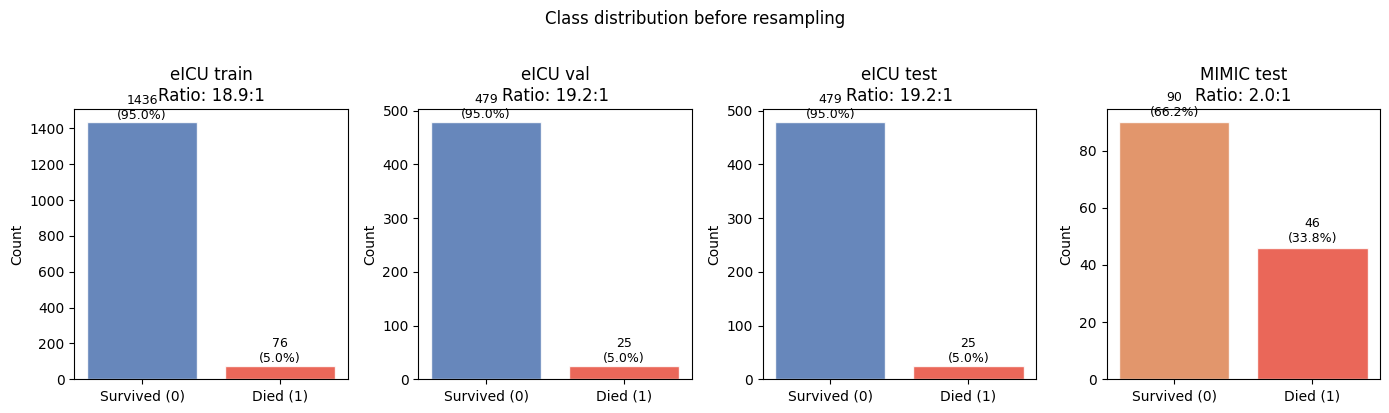

In [20]:
#  Visualise imbalance before resampling

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, y, name, color in zip(
    axes,
    [y_train, y_val, y_test, y_mimic],
    ['eICU train', 'eICU val', 'eICU test', 'MIMIC test'],
    ['#4C72B0', '#4C72B0','#4C72B0', '#DD8452' ]
):
    counts = y.value_counts()
    bars = ax.bar(['Survived (0)', 'Died (1)'], [counts.get(0,0), counts.get(1,0)],
                  color=[color, '#e74c3c'], alpha=0.85, edgecolor='white')
    for bar, count in zip(bars, [counts.get(0,0), counts.get(1,0)]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{count}\n({count/len(y)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{name}\nRatio: {counts.get(0,0)/max(counts.get(1,1),1):.1f}:1')
    ax.set_ylabel('Count')

plt.suptitle('Class distribution before resampling', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# SMOTE only
# k_neighbors=5 is default; reduce if minority class has few samples
n_minority = Counter(y_train)[1]
k = min(5, n_minority - 1)  # safe k

smote = SMOTE(random_state=SEED, k_neighbors=k)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f'SMOTE resampled:')
print(f'  Before: {Counter(y_train)}')
print(f'  After:  {Counter(y_train_smote)}')
print(f'  New shape: {X_train_smote.shape}')

SMOTE resampled:
  Before: Counter({0: 1436, 1: 76})
  After:  Counter({0: 1436, 1: 1436})
  New shape: (2872, 100)


In [22]:
# SMOTETomek (SMOTE + boundary cleaning)
# Slightly more aggressive — removes ambiguous majority samples near the boundary
smt = SMOTETomek(random_state=SEED,
                 smote=SMOTE(random_state=SEED, k_neighbors=k))
X_train_smt, y_train_smt = smt.fit_resample(X_train_scaled, y_train)

print(f'SMOTETomek resampled:')
print(f'  Before: {Counter(y_train)}')
print(f'  After:  {Counter(y_train_smt)}')
print(f'  New shape: {X_train_smt.shape}')

SMOTETomek resampled:
  Before: Counter({0: 1436, 1: 76})
  After:  Counter({0: 1436, 1: 1436})
  New shape: (2872, 100)


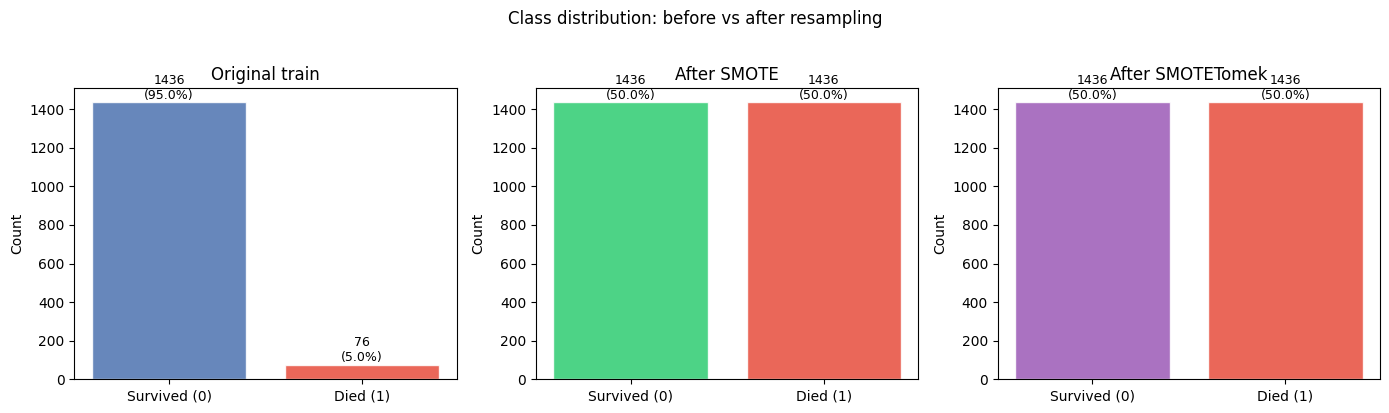


Note: resampling applied to TRAIN set only.
Val and MIMIC sets remain unchanged (real-world distribution).


In [23]:
# Visualise after resampling
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets = [
    (y_train,       'Original train',      '#4C72B0'),
    (y_train_smote, 'After SMOTE',         '#2ecc71'),
    (y_train_smt,   'After SMOTETomek',    '#9b59b6'),
]
for ax, (y, name, color) in zip(axes, datasets):
    counts = Counter(y)
    bars = ax.bar(['Survived (0)', 'Died (1)'], [counts[0], counts[1]],
                  color=[color, '#e74c3c'], alpha=0.85, edgecolor='white')
    for bar, count in zip(bars, [counts[0], counts[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{count}\n({count/sum(counts.values())*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(name)
    ax.set_ylabel('Count')

plt.suptitle('Class distribution: before vs after resampling', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('\nNote: resampling applied to TRAIN set only.')
print('Val and MIMIC sets remain unchanged (real-world distribution).')

In [24]:
# UPDATE SUGGESTION: use SMOTE inside cross-validation folds to prevent leakage during model selection.
# Pre-applying SMOTE before CV allows synthetic samples to leak across folds.
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

n_minority = Counter(y_train)[1]
k_safe = min(5, n_minority - 1)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

pipeline_with_smote = ImbPipeline([
    ('smote', SMOTE(random_state=SEED, k_neighbors=k_safe)),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])

cv_results = cross_validate(
    pipeline_with_smote, X_train_scaled, y_train,
    cv=cv_strategy,
    scoring=['roc_auc', 'average_precision']
)

print('CV with SMOTE-inside-fold (example with Logistic Regression):')
print(f'  ROC-AUC : {cv_results["test_roc_auc"].mean():.3f} +/- {cv_results["test_roc_auc"].std():.3f}')
print(f'  Avg Prec: {cv_results["test_average_precision"].mean():.3f} +/- {cv_results["test_average_precision"].std():.3f}')


CV with SMOTE-inside-fold (example with Logistic Regression):
  ROC-AUC : 0.740 +/- 0.052
  Avg Prec: 0.273 +/- 0.117


In [25]:
# Compute class weights for sklearn models
# This is used as: LogisticRegression(class_weight=CLASS_WEIGHTS)
# It penalises misclassifying the minority class more heavily
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
CLASS_WEIGHTS = {0: class_weights_array[0], 1: class_weights_array[1]}
print(f'Class weights (for sklearn models):')
print(f'  Class 0 (survived): {CLASS_WEIGHTS[0]:.3f}')
print(f'  Class 1 (died):     {CLASS_WEIGHTS[1]:.3f}')
print(f'  Ratio: 1 : {CLASS_WEIGHTS[1]/CLASS_WEIGHTS[0]:.1f}')

Class weights (for sklearn models):
  Class 0 (survived): 0.526
  Class 1 (died):     9.947
  Ratio: 1 : 18.9


In [26]:
# Final verification of all splits
import pandas as pd
from collections import Counter

splits = {
    'X_train (scaled)':       (X_train_scaled, y_train),
    'X_val (scaled)':         (X_val_scaled,   y_val),
    'X_test (scaled)':        (X_test_scaled,  y_test),
    'X_mimic (scaled)':       (X_mimic_scaled, y_mimic),
    'X_train SMOTE':          (pd.DataFrame(X_train_smote,
                                columns=X_train_scaled.columns),
                                pd.Series(y_train_smote)),
}

print('=' * 65)
print(f'{"Split":<22} {"Shape":<14} {"NaN":>5} {"Mort%":>7} {"Cols":>5}')
print('-' * 65)
for name, (X, y) in splits.items():
    nan_count = X.isnull().sum().sum()
    mort      = y.mean() * 100
    n_cols    = X.shape[1]
    all_flags = ['albumin_was_missing','lactate_was_missing','alt_was_missing',
                         'sbp_was_missing','dbp_was_missing','map_was_missing','inr_was_missing']
    flag_ok   = '✓' if all(f in X.columns for f in all_flags) else '✗'
    print(f'{name:<22} {str(X.shape):<14} {nan_count:>5} {mort:>6.1f}%  {n_cols:>3} {flag_ok}')

print('=' * 65)

# Column consistency check
ref_cols = set(X_train_scaled.columns)
print('\nColumn consistency (vs X_train):')
for name, (X, _) in splits.items():
    diff = ref_cols.symmetric_difference(set(X.columns))
    status = '✓ identical' if not diff else f'✗ diff: {diff}'
    print(f'  {name:<25} {status}')

# Dtype check, everything must be numeric after OHE + scaling
print('\nData types (should all be float64 or int):')
for name, (X, _) in splits.items():
    obj_cols = X.select_dtypes(include='object').columns.tolist()
    status = '✓ all numeric' if not obj_cols else f'✗ object cols: {obj_cols}'
    print(f'  {name:<25} {status}')

print('\nFirst 5 rows of X_train_scaled (first 8 cols):')
display(X_train_scaled.iloc[:5, :8].round(3))

print('\nFirst 5 rows of X_mimic_scaled (first 8 cols):')
display(X_mimic_scaled.iloc[:5, :8].round(3))

print('\nTarget distributions:')
for name, (_, y) in splits.items():
    c = Counter(y)
    print(f'  {name:<25} 0={c[0]:>4}  1={c[1]:>4}  ratio={c[0]/max(c[1],1):.1f}:1')

Split                  Shape            NaN   Mort%  Cols
-----------------------------------------------------------------
X_train (scaled)       (1512, 100)        0    5.0%  100 ✓
X_val (scaled)         (504, 100)         0    5.0%  100 ✓
X_test (scaled)        (504, 100)         0    5.0%  100 ✓
X_mimic (scaled)       (136, 100)         0   33.8%  100 ✓
X_train SMOTE          (2872, 100)        0   50.0%  100 ✓

Column consistency (vs X_train):
  X_train (scaled)          ✓ identical
  X_val (scaled)            ✓ identical
  X_test (scaled)           ✓ identical
  X_mimic (scaled)          ✓ identical
  X_train SMOTE             ✓ identical

Data types (should all be float64 or int):
  X_train (scaled)          ✓ all numeric
  X_val (scaled)            ✓ all numeric
  X_test (scaled)           ✓ all numeric
  X_mimic (scaled)          ✓ all numeric
  X_train SMOTE             ✓ all numeric

First 5 rows of X_train_scaled (first 8 cols):


,age_clean,albumin_max,albumin_mean,albumin_min,alt_max,alt_mean,alt_min,bicarbonate_max
36,-0.937,-2.420,-2.534,-2.621,-0.117,-0.123,-0.133,0.455
259,-1.340,0.008,0.029,0.048,-0.157,-0.157,-0.158,-0.023
249,-1.858,0.008,0.029,0.048,-0.157,-0.157,-0.158,1.409
2290,0.387,1.554,1.144,0.715,-0.030,-0.060,-0.092,-0.739
1942,0.156,1.554,1.590,1.605,-0.291,-0.287,-0.289,-0.023



First 5 rows of X_mimic_scaled (first 8 cols):


,age_clean,albumin_max,albumin_mean,albumin_min,alt_max,alt_mean,alt_min,bicarbonate_max
0,0.387,-0.433,-0.416,-0.397,-0.157,-0.157,-0.158,1.409
1,-1.570,-0.654,-0.639,-0.619,1.611,1.632,1.692,-0.500
2,1.365,0.008,0.029,0.048,-0.165,-0.159,-0.158,0.932
3,0.559,-0.212,-0.194,-0.174,-0.157,-0.157,-0.158,0.932
4,-0.880,0.008,0.029,0.048,0.830,0.844,0.878,-1.693



Target distributions:
  X_train (scaled)          0=1436  1=  76  ratio=18.9:1
  X_val (scaled)            0= 479  1=  25  ratio=19.2:1
  X_test (scaled)           0= 479  1=  25  ratio=19.2:1
  X_mimic (scaled)          0=  90  1=  46  ratio=2.0:1
  X_train SMOTE             0=1436  1=1436  ratio=1.0:1


In [27]:
import pickle

# Save all splits as CSV
pd.DataFrame(X_train_scaled, columns=X_train.columns).to_csv(f'{OUT_DIR}/X_train.csv', index=False)
pd.DataFrame(X_val_scaled,   columns=X_val.columns  ).to_csv(f'{OUT_DIR}/X_val.csv',   index=False)
pd.DataFrame(X_test_scaled,  columns=X_test.columns ).to_csv(f'{OUT_DIR}/X_test.csv',  index=False)
pd.DataFrame(X_mimic_scaled, columns=X_mimic.columns).to_csv(f'{OUT_DIR}/X_mimic.csv', index=False)
y_train.to_csv(f'{OUT_DIR}/y_train.csv', index=False)
y_val.to_csv(  f'{OUT_DIR}/y_val.csv',   index=False)
y_test.to_csv( f'{OUT_DIR}/y_test.csv',  index=False)
y_mimic.to_csv(f'{OUT_DIR}/y_mimic.csv', index=False)

# Save SMOTE versions
pd.DataFrame(X_train_smote, columns=X_train.columns).to_csv(f'{OUT_DIR}/X_train_smote.csv', index=False)
pd.Series(y_train_smote, name='mortality').to_csv(f'{OUT_DIR}/y_train_smote.csv', index=False)

# Save preprocessing objects for reproducibility
preprocessing = {
    'num_imputer':     num_imputer,
    'scaler':          scaler,
    'continuous_cols': continuous_cols,
    'clip_bounds':     clip_bounds,
    'train_cols':      train_cols_after_ohe,
    'class_weights':   CLASS_WEIGHTS,
}
with open(f'{OUT_DIR}/preprocessing_objects.pkl', 'wb') as f:
    pickle.dump(preprocessing, f)

print('Saved:', os.listdir(OUT_DIR))

Saved: ['X_train.csv', 'X_val.csv', 'X_test.csv', 'X_mimic.csv', 'y_train.csv', 'y_val.csv', 'y_test.csv', 'y_mimic.csv', 'X_train_smote.csv', 'y_train_smote.csv', 'preprocessing_objects.pkl']


# Preprocessing Summary

## Steps performed

**1. Column mismatch** — eICU vital sign columns renamed to match MIMIC naming
convention (`heartrate_*` → `hr_*`, `sao2_*` → `spo2_*`, etc.). Result: 73 shared
columns across both datasets.

**2. Leaky/ID columns dropped** — `stay_id`, `dataset`, and `icu_los_days` removed.
`icu_los_days` excluded because length of stay is only known at discharge, which
coincides with the mortality outcome (look-ahead bias).

**3. High-missingness features dropped** — Only `temperature` (94% missing in both
datasets) removed. BP (SBP/DBP/MAP, ~84% missing in eICU) and INR (~74% missing in
eICU) are **protected** — they are well-measured in MIMIC (~3%/20%) and critical for
external validation. `lactate_*` and `bun_*` also protected despite borderline
missingness due to strong EDA correlation with mortality.

**4. Train/validation/test split (60/20/20)** — eICU stratified split preserving
5% mortality rate across all folds. MIMIC held out entirely as external validation
(never seen during any fitting step).

| Split | n | Mortality |
|---|---|---|
| eICU train | 1,512 | 5.0% |
| eICU val | 504 | 5.0% |
| eICU test | 504 | 5.0% |
| MIMIC external | 136 | 33.8% |

**5. Outlier capping** — numeric features clipped at 1st–99th percentile bounds
computed on training set only, applied to all splits. Removes physiologically
implausible values (e.g. ALT = 5,610 U/L observed in EDA).

**6. Missingness indicator flags** — 7 binary flags added across two groups:

| Flag | Train rate | Clinical meaning |
|---|---|---|
| `albumin_was_missing` | 56.3% | Albumin not ordered |
| `lactate_was_missing` | 81.0% | Lactate not ordered |
| `alt_was_missing` | 60.7% | ALT not ordered |
| `sbp_was_missing` | 84.6% | BP not recorded (eICU-specific gap) |
| `dbp_was_missing` | 84.6% | BP not recorded (eICU-specific gap) |
| `map_was_missing` | 84.5% | MAP not recorded (eICU-specific gap) |
| `inr_was_missing` | 75.2% | INR not ordered |

**7. Imputation** — median imputation for 62 numeric features (fit on train only);
mode imputation for 4 categorical features. Zero NaN remaining in all splits.

**8. One-hot encoding** — 4 categorical columns encoded with `drop_first=True`
(`careunit`, `admit_source`, `ethnicity_grp`, `icd9_chapter`). `drop_first=True`
removes the reference dummy to prevent multicollinearity in linear models. MIMIC
reindexed to training column set. Final feature count: **100 columns**.

**9. Standardisation** — `StandardScaler` fit on `X_train` only, applied to
**61 continuous features**. OHE dummies and binary flags are excluded from scaling
to preserve their 0/1 semantics.

**10. Class imbalance** — eICU training set has an 18.9:1 majority/minority ratio.
Three complementary strategies prepared:

| Strategy | Mechanism | Use with |
|---|---|---|
| SMOTE | Synthetic minority oversampling → balanced 1:1 | Any model |
| SMOTETomek | SMOTE + boundary cleaning | Any model |
| `class_weight='balanced'` | Penalises minority misclassification | sklearn models |
| SMOTE-in-CV pipeline | SMOTE applied per fold via `imblearn.Pipeline` | CV model selection |

SMOTE applied **only to training set** after splitting. Validation, test, and MIMIC
sets retain the original class distribution to reflect real-world conditions.

## Leakage prevention checklist
- All fitting steps (imputer, scaler, clip bounds) fit on `X_train` only
- MIMIC never used in any fitting step
- SMOTE applied after split, to train only
- `icu_los_days` excluded (future information)
- Flags created before imputation (flag captures original missingness)
- `drop_first=True` on OHE (no multicollinearity)
- Scaler applied to continuous features only (flags/dummies untouched)

## Output files
```
preprocessed/
├── X_train.csv          (1512 × 100)
├── X_val.csv            ( 504 × 100)
├── X_test.csv           ( 504 × 100)
├── X_mimic.csv          ( 136 × 100)
├── y_train/val/test/mimic.csv
├── X_train_smote.csv    (2872 × 100)
├── y_train_smote.csv
└── preprocessing_objects.pkl  (imputer, scaler, continuous_cols, clip_bounds, train_cols, class_weights)
```
